# Livrable Final


In [20]:
import tensorflow as tf 
import numpy as np 
import matplotlib.pyplot as plt


## Objectifs
L'objectif de ce livrable final est de présenter la restauration des images de légendes. Nous utilisons notre auto-encodeur performant (U-Net) pour nettoyer les images bruitées et retrouver la clarté originale.


## Opération de débruitage

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step


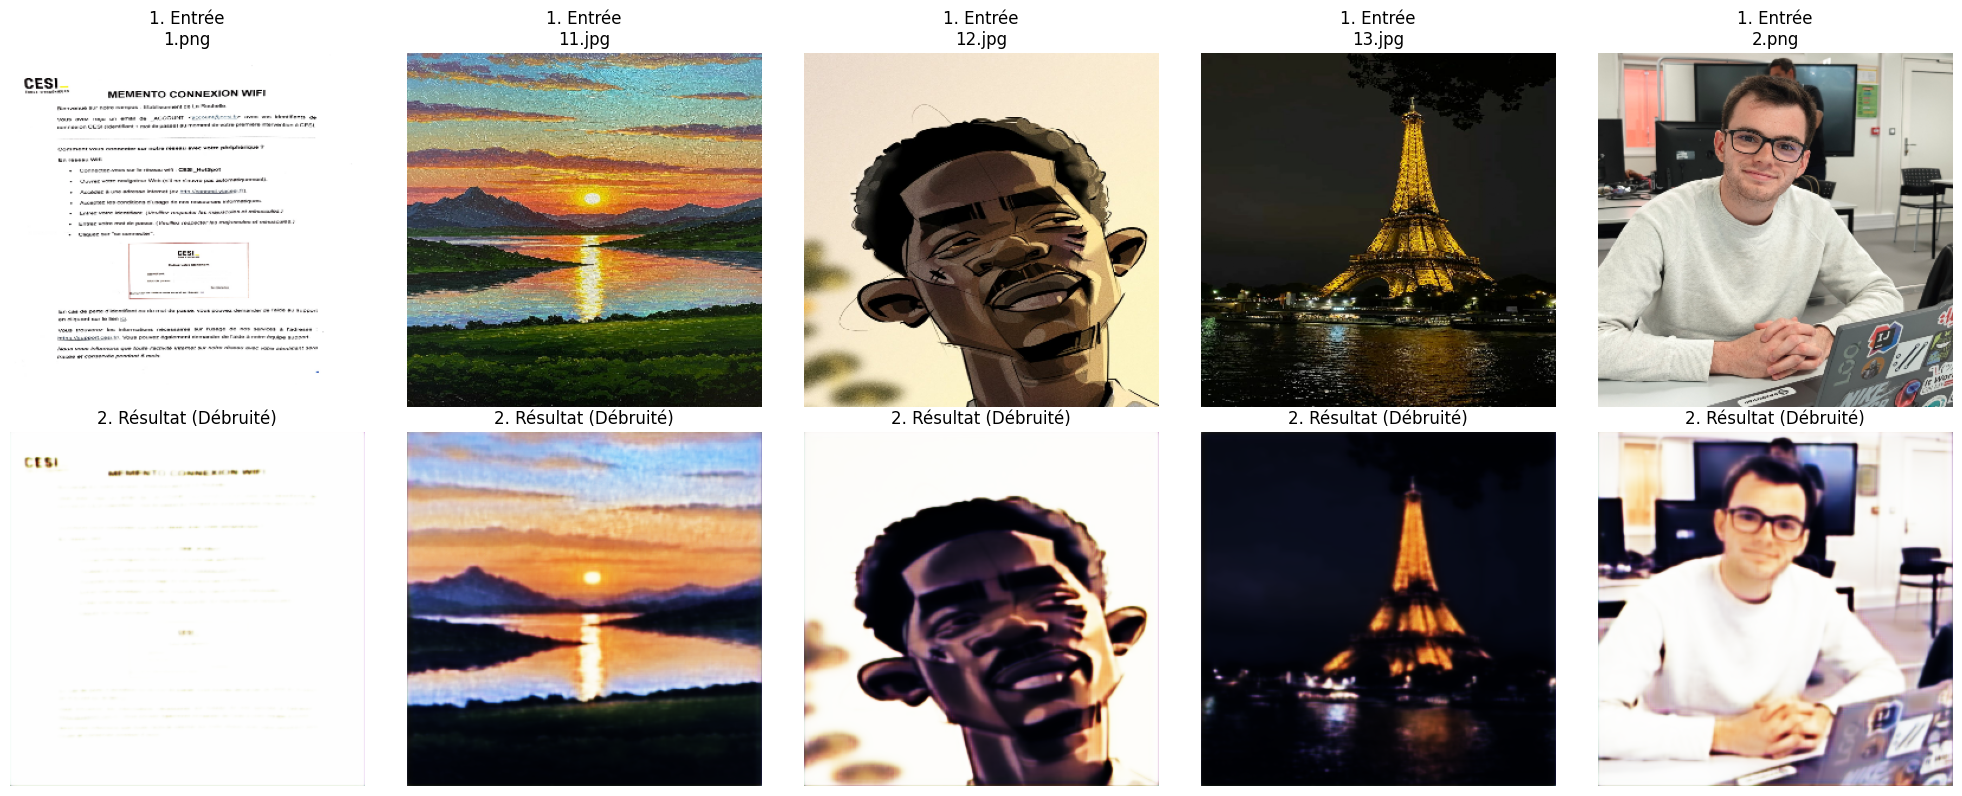

In [4]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import numpy as np

# 1. Chargement du modèle d'auto-encodeur (denoiser)
# Ce modèle utilise maintenant l'architecture U-Net (Skip Connections) pour plus de détails
model_path = "models/livrable2/autoencoder.keras"
if os.path.exists(model_path):
    model_charge = tf.keras.models.load_model(model_path)
else:
    raise FileNotFoundError(f"Modèle introuvable à : {model_path}. Assurez-vous d'avoir lancé l'entraînement dans Livrable 2.")

# 2. Préparation des images de datasets/final
img_dir = "datasets/final"  # Chemin corrigé
if not os.path.exists(img_dir):
    raise FileNotFoundError(f"Dossier '{img_dir}' introuvable.")

# Récupération des images
image_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
if not image_files:
    raise FileNotFoundError(f"Aucune image trouvée dans '{img_dir}'.")
image_paths = [os.path.join(img_dir, f) for f in image_files]

def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [300, 300]) # Taille 300x300 pour l'auto-encodeur
    img = tf.cast(img, tf.float32) / 255.0  # Normalisation [0, 1]
    return img

# Création du dataset
path_ds = tf.data.Dataset.from_tensor_slices(image_paths)
# On utilise un batch de 5 pour la visualisation
test_set_noisy = path_ds.map(load_and_preprocess).batch(5)

# 3. Prédiction et visualisation
for images_batch in test_set_noisy.take(1):
    # L'IA effectue le nettoyage (Encodeur -> Espace Latent -> Décodeur + Skip Connections)
    images_denoised = model_charge.predict(images_batch)

    n = len(images_batch)
    plt.figure(figsize=(20, 8))

    for i in range(n):
        # Ligne 1 : Image d'entrée (peut être bruitée ou non)
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(images_batch[i].numpy())
        plt.title(f"1. Entrée\n{image_files[i]}")
        plt.axis("off")

        # Ligne 2 : Sortie du Denoiseur
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(images_denoised[i])
        plt.title("2. Résultat (Débruité)")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


## Classification binaire (Photo / Pas Photo)
Dans cette étape, nous utilisons le modèle de classification amélioré pour déterminer si l'image restaurée est une photo ou un autre type de document.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


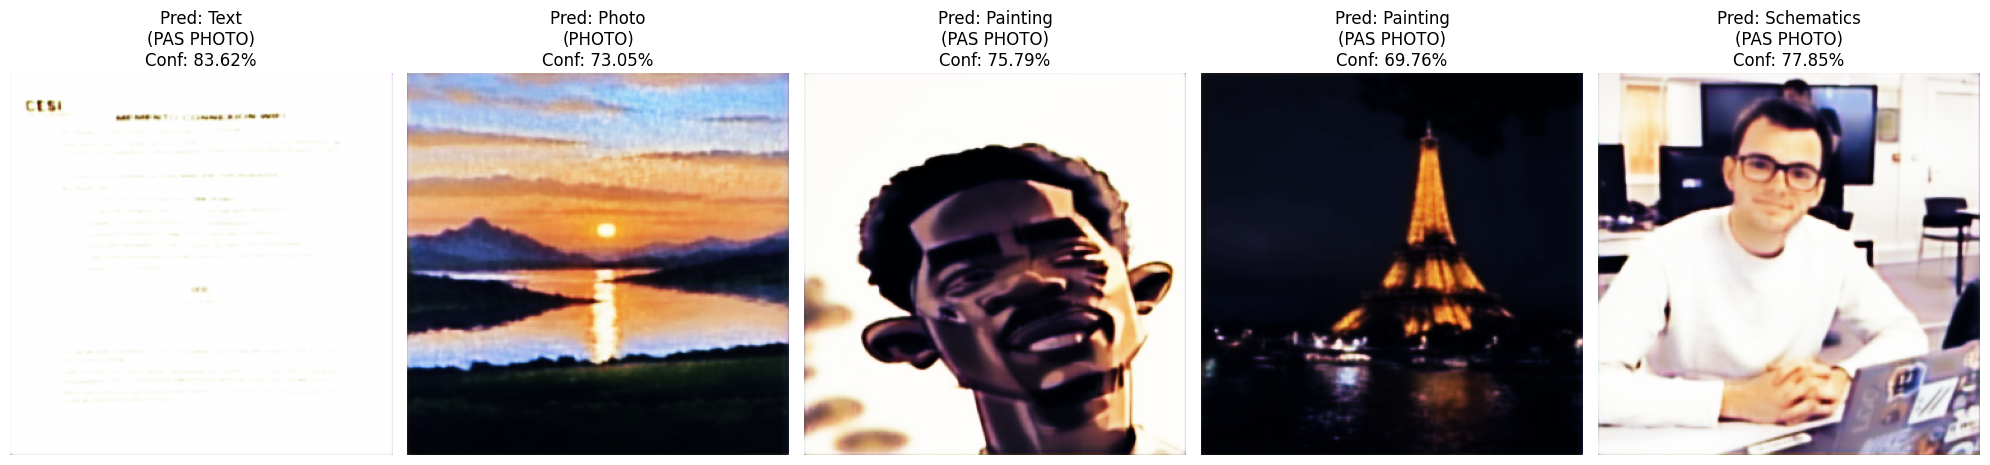

In [5]:
from tensorflow import keras

# 1. Chargement du modèle de classification amélioré
classifier_model = keras.models.load_model('models/livrable1/improved_model.keras', compile=False)

# Définition des classes (identiques à l'entraînement du Livrable 1)
class_names = ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']

# 2. Adaptation des images pour le classifieur
# L'auto-encodeur sort des valeurs en [0.0, 1.0]. 
# Le classifieur improved_model attend des valeurs en [0, 255] car il a une couche Rescaling(1./255) interne.
images_denoised_255 = images_denoised * 255.0
images_for_classifier = tf.image.resize(images_denoised_255, [180, 180])

# 3. Prédiction et calcul des probabilités avec Softmax
predictions = classifier_model.predict(images_for_classifier)
score = tf.nn.softmax(predictions)

# 4. Affichage des résultats
plt.figure(figsize=(20, 10))
for i in range(len(images_denoised)):
    ax = plt.subplot(1, len(images_denoised), i + 1)
    plt.imshow(images_denoised[i]) # Affichage en [0, 1] pour matplotlib
    
    idx_max = np.argmax(score[i])
    predicted_class = class_names[idx_max]
    confidence = 100 * np.max(score[i])
    
    # Classification binaire basée sur la classe prédite
    is_photo = "PHOTO" if predicted_class == "Photo" else "PAS PHOTO"
    
    plt.title(f"Pred: {predicted_class}\n({is_photo})\nConf: {confidence:.2f}%")
    plt.axis("off")

plt.tight_layout()
plt.show()
